# Salt Lake City AQI Predictions and Forecasting

*Basic Info:*                                                                      

Title: Salt Lake City AQI Predictions and Forecasting.                                                 

Team Members:                                                         
+ Michael Northrup, u0992000,  michael.northrup@yahoo.com
+ Grant (Rob) Olsen, u0684253, rolsenrob@gmail.com
+ Dzevad Fitozovic, u0191522, dfitozovic@hotmail.com



## Background and Motivation.

We think that the quality of our air here in the valley is often a topic of discussion. However, the primary motivation came from one of our assignments. There we attempted to use the AQI to give us a moving average in order to be able to issue a warning to sensitive groups when an upwards trend was most likely occurring. We wanted to improve and expand on that, so in this project we want to see if we can predict the AQI for a few days in advance, creating a forecast for up to a week in advance. We also wish to see if we can make an AQI long term forecast model, so that one would be able to see how many days of poor air quality we can expect to see as our valley population rises. We do not have a background nor have we done any research in the area, but it seemed like an interesting problem. 

## Project Objectives.

Our primary objective is to devise a model to obtain an AQI forecast much like we have a weather forecast.  Additionally, we would like to know how population growth in the valley will be affecting the number of days the AQI will reach over 101, therefore creating a forecast for future years based primarily on population growth. Population growth seems like a good measure for the increasing days of unhealthy air since it drives the amount of energy used, for example from heating and air conditioning of homes and cars on the roads in the valley. On the other hand short term AQI data combined with weather forecasts should be useful in creating a short term forecast model. A short term model can be useful in warning sensitive groups of upcoming poor air quality days. And, if we can create a good predictive long term model, then it can be used as supporting evidence for a need to make a valley wide plan for future energy consumption that could limit the amount of pollutants like PM2.5 which accumulate due to our natural inversion conditions. Additionally, we would like inform our discussion by looking at attitudes for some of the measures which have been implemented or could be implemented, such as limiting use of wood burning fireplaces, addition of more public transportation, and/or if people, in general, take it seriously as an issue. For example trying to see if more people carpool and take public transportation on bad air days and other measures during mandatory action days.

## Data.

We needed to gather and clean a significant amount of data from several sources. For the long term projection model the air quality data was collected from https://www.epa.gov/outdoor-air-quality-data. However, each year comes as a separate data-file so it needed to be combined. To calculate projections for population growth we obtained Salt Lake Valley census data from http://www.census.gov/popest/data/index.html, and followed links to historical data for years after 2010. Data formats from this source varied since the most recent years use newer data formats. For our short term forecasting we will need an accurate 1-7 day weather forecast for the valley and previous days AQI, which we'll obtain by either web scraping http://www.weather.gov/ or an API (to be determined). However, we may need further data sources as we continue to process the data from these sites. Some preliminary data analysis, formatting and cleanup as well as a population plot was included in this proposal. 

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt 
%pylab inline
%matplotlib inline  
plt.rcParams['figure.figsize'] = (14, 8)


Populating the interactive namespace from numpy and matplotlib


## Data Processing. 

Some of the cleanup for the population data and short term climate data was completed in OpenOffice out of convenience. Data clean up in the long term model air quality data set was comparable to the cleanup in Homework #3, although there is a lot more data which needed to be cleaned and combined. On the other hand, we saw a bit more complexity in data cleanup of the population growth data and we expect substantial data cleanup in use of the API for the most recent weather forecasts. We expect that we should be able to give a fairly accurate short term AQI prediction, namely what type of air quality day one expects to have in the upcoming days, and long term projections based on population growth of at least 1-5 years in advance, assuming a reasonable amount of uncertainty and that current trends continue indefinitely.

In [6]:
# load climate data from Oct. 1st to Oct. 26th for use in short term forecasting. 
Oct_weather_data_slv = pd.read_csv("recent_climate_data.txt")
# create weather symbols list from original october climate data 
weather_symbols = pd.Series(['FOG OR MIST', 'FOG REDUCING VISIBILITY TO 1/4 MILE OR LESS', 'THUNDER', 'ICE PELLETS', 'HAIL',
                            'FREEZING RAIN OR DRIZZLE', 'DUSTSTORM OR SANDSTORM: VSBY 1/2 MILE OR LESS', 'SMOKE OR HAZE',
                            'BLOWING SNOW','TORNADO'],
                         name="Weather Type",
                         index=["1", "2", "3", "4", "5", "6", "7", "8", "9", "X"])
print(weather_symbols)
Oct_weather_data_slv

1                                      FOG OR MIST
2      FOG REDUCING VISIBILITY TO 1/4 MILE OR LESS
3                                          THUNDER
4                                      ICE PELLETS
5                                             HAIL
6                         FREEZING RAIN OR DRIZZLE
7    DUSTSTORM OR SANDSTORM: VSBY 1/2 MILE OR LESS
8                                    SMOKE OR HAZE
9                                     BLOWING SNOW
X                                          TORNADO
Name: Weather Type, dtype: object


,Day of month,MAX Temp (F),MIN Temp (F),AVG Temp (F),DEP,HDD,CDD,Percipitation (inch),Snow,12ZDPTH,Avg wind speed (mph),Max wind speed (mph),2minDIR,MIN,PSBL,Weather type,WX,Peak wind speed,Wind direction (deg)
0,1,81,58,70,11,0,5,T,0.0,0,11.8,26,170,M,M,3,3.0,33,160
1,2,81,55,68,9,0,3,0.01,0.0,0,13.5,32,190,M,M,7,3.0,49,210
2,3,66,46,56,-2,9,0,T,0.0,0,14.0,31,260,M,M,6,3.0,42,260
3,4,60,41,51,-7,14,0,0.00,0.0,0,7.4,14,320,M,M,4,NaN,19,360
4,5,58,41,50,-7,15,0,0.10,0.0,0,7.3,28,290,M,M,7,3.0,35,280
5,6,59,38,49,-8,16,0,0.01,0.0,0,6.4,13,220,M,M,2,NaN,18,190
6,7,68,40,54,-2,11,0,0.00,0.0,0,7.0,15,350,M,M,1,NaN,23,330
7,8,71,41,56,0,9,0,0.00,0.0,0,5.6,10,330,M,M,3,NaN,15,350
8,9,77,45,61,5,4,0,0.00,0.0,0,6.9,14,130,M,M,1,NaN,16,140
9,10,80,55,68,13,0,3,0.00,0.0,0,11.4,24,180,M,M,3,NaN,31,180


In [7]:
# load salt lake county population data for years 1990 through 2015
sl_county_1990to2015 = pd.read_csv("popEstimate_SL_county_1990-2015.csv")
sl_county_1990to2015

,NAME,STNAME,ESTIMATESBASE1990,POPESTIMATE1991,POPESTIMATE1992,POPESTIMATE1993,POPESTIMATE1994,POPESTIMAT1995,POPESTIMATE1996,POPESTIMATE1997,...,POPESTIMATE2006,POPESTIMATE2007,POPESTIMATE2008,POPESTIMATE2009,CENSUS2010POP.1,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014,POPESTIMATE2015
0,Salt Lake County,Utah,729893,751023,774408,798049,819039,836008,853076,871580,...,947963,966798,983719,999553,1016795,1033182,1048686,1064745,1081155,1092888


## Exploratory Analysis.

We will plot population VS. number of days AQI is over 101 and apply regression analysis and extrapolation on this data. We will also attempt to visualize how precipitation, temperature and wind speed effect the short term prediction model. Additionally, we will also plot the number of mentions about our bad air and see if it matches the actual poor AQI. A simple population plot vs. time in years was added below as part of preliminary analysis.

C:\Anaconda3\lib\site-packages\ipykernel\__main__.py:4: FutureWarning: 
The default value for 'return_type' will change to 'axes' in a future release.
 To use the future behavior now, set return_type='axes'.
 To keep the previous behavior and silence this warning, set return_type='dict'.


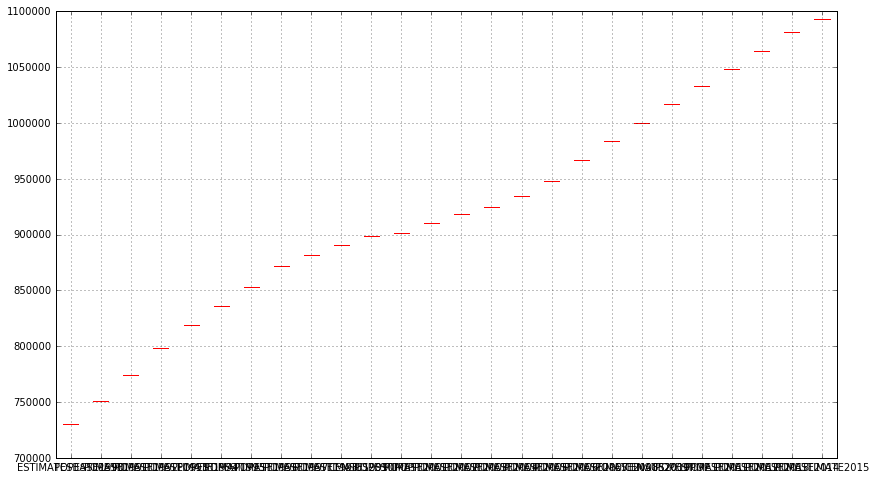

In [5]:
# preliminary unformulated plot of population over time
sl_county_1990to2015_data = sl_county_1990to2015.drop(['NAME'], axis = 1)
sl_county_1990to2015_data = sl_county_1990to2015.drop(['STNAME'], axis = 1)
sl_county_1990to2015_data.boxplot();

## Analysis Methodology.

For our short term model, we will combine the weather predictions and past month data to create a forecast model for up to a week in advance. On the other hand, for the long term model we will see how well population growth is correlated with past population growth by looking at past population data and AQI than projecting for years to come. Then expand the model by including past climate information to normalize for drier than average years.

## Project Schedule. 

We plan on mostly working together to achieve each project deadline. However, some work will need to be divided out if we are unable to reach each week's objective during team meetings. 

By Friday 11-04-16
+ Obtain and format long term climate, population and AQI data. (Dzevad)
+ Obtain and format short term climate and AQI data. (Michael) 
+ Obtain current weather forecast using an API. (Rob)

By Friday 11-11-16 
+ Create a long term forecasting model and test it on year 2015. (Rob, Michael and Dzevad) 
+ Create a short term forecasting model and check if it is able to predict a few days ahead. (Rob, Michael and Dzevad) 

By Friday 11-18-16
+ Tested the short term and long term model. (Rob, Michael and Dzevad)
+ Created plots to help visualize the data. (Rob, Michael and Dzevad)
+ Turn in project milestone. (Rob, Michael and Dzevad)

By Wednesday 11-23-16 
+ Refine the short term and long term model. (Rob, Michael and Dzevad)
+ Begin creating Project Screen-Cast. (Rob, Michael and Dzevad)
+ Begin creating presentation. (Rob, Michael and Dzevad)

By Friday 12-02-16
+ Completed AQI perdition and forecasting project notebook. (Rob, Michael and Dzevad)
+ Completed Project Screen-Cast and presentation. (Rob, Michael and Dzevad)

